# Projects in data science: Decision Tree and Ensemble

## Exercise 1: Decision Tree
* Create a dataset with 2 features using the [make_classification function](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) of scikit-learn. See a more detailed tutorial here: [How to Generate Datasets Using make_classification](https://proclusacademy.com/blog/sklearn_make_classification/)
* Train and evaluate a [Decision Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) on the dataset
* Visualize the [decision boundary](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html)
* Use the [drawdata python library](https://github.com/koaning/drawdata) to create different datasets, train a decision tree, and look at the [tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) and decision boundary

Train accuracy: 1.0
Mean accuracy: 0.575


<Figure size 640x480 with 0 Axes>

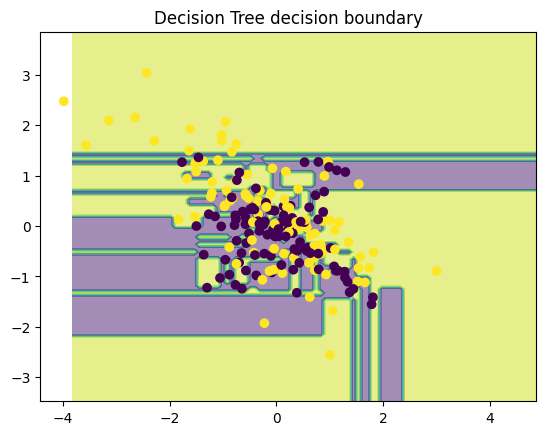

In [3]:
#Your answer
#Import libraries
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

#1
#Create a dataset
X, y = make_classification(n_samples=1000, n_features=2,n_informative=2,n_redundant=0,n_repeated=0,class_sep=0.2,random_state=1907)
#Split into train and test
x_train,x_val,y_train,y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=1907)

#2
#Create, fit and evaluate a Decision Tree 
decision_tree = DecisionTreeClassifier(random_state=1907) # there might be randomness in how the tree handles ties, so we set the random state for reproducibility
decision_tree.fit(x_train,y_train)
print(f"Train accuracy: {decision_tree.score(x_train,y_train)}")
print(f"Mean accuracy: {decision_tree.score(x_val,y_val)}")

#3
#Plot model's decision boundary and test data
plt.figure()
DecisionBoundaryDisplay.from_estimator(decision_tree,x_train,alpha=0.5)
plt.scatter(x_val[:,0],x_val[:,1],c=y_val)
plt.title("Decision Tree decision boundary")
plt.show()

### Question 1
#### What can you observe from this decision boundary?

There are some tiny rectangles which suggest overfitting to training data. Besides training accuracy is perfect, whereas the validation accuracy is pretty low. We should aim for similar accuracy values in both the training and validation sets.

### Question 2
#### What can you observe from the shape of this decision tree?

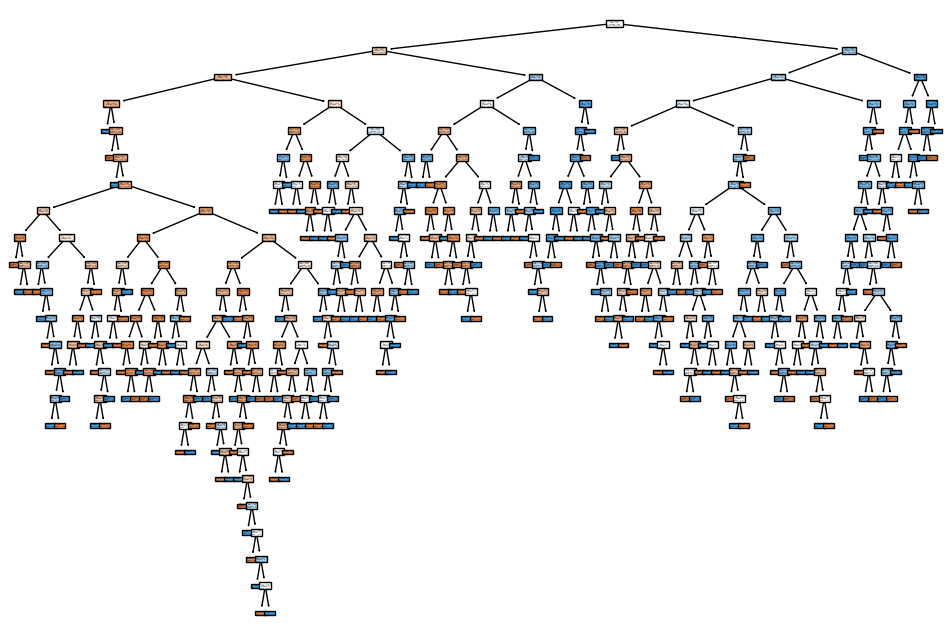

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(decision_tree, filled=True) #filled=True colors the nodes according to the majority class
plt.show()

**Answer:** It looks very deep, so we should set max_depth to a relatively small number e.g. 3 or 5.

max_depth= 3 - Train accuracy: 0.685 - Val accuracy: 0.63
max_depth= 4 - Train accuracy: 0.74 - Val accuracy: 0.66
max_depth= 5 - Train accuracy: 0.76125 - Val accuracy: 0.66
max_depth= 6 - Train accuracy: 0.7825 - Val accuracy: 0.645
max_depth= 7 - Train accuracy: 0.80125 - Val accuracy: 0.635
max_depth= 8 - Train accuracy: 0.8225 - Val accuracy: 0.635


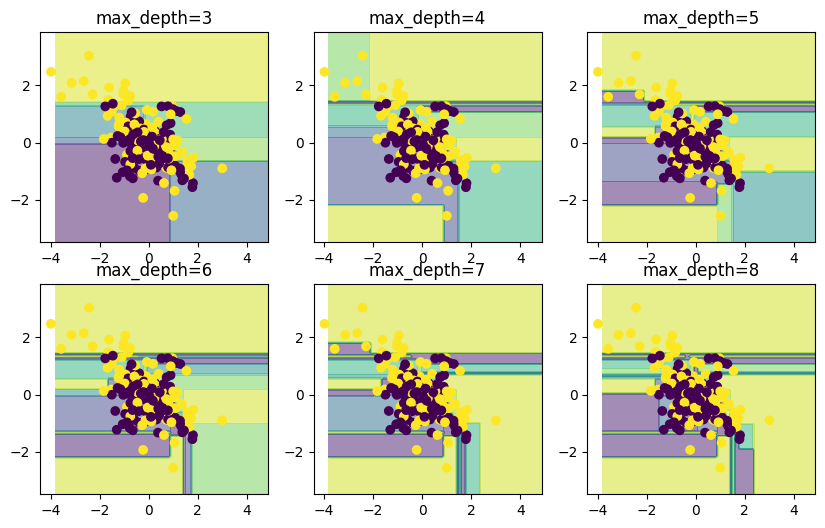

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))
depths = range(3, 9)

for i, d in enumerate(depths):
    decision_tree = DecisionTreeClassifier(max_depth=d, random_state=1907)
    decision_tree.fit(x_train,y_train)

    # plot
    row, col = i // 3, i % 3
    DecisionBoundaryDisplay.from_estimator(decision_tree,x_train,alpha=0.5, ax=ax[row, col])
    ax[row, col].scatter(x_val[:,0],x_val[:,1],c=y_val)
    ax[row, col].set_title(f"max_depth={d}")
    print(f"max_depth= {d} - Train accuracy: {decision_tree.score(x_train,y_train)} - Val accuracy: {decision_tree.score(x_val,y_val)}")

### drawdata widget

In [30]:
!pip install drawdata

Defaulting to user installation because normal site-packages is not writeable


In [1]:
from drawdata import ScatterWidget

widget = ScatterWidget()
widget

Train accuracy: 1.0
Validation accuracy: 1.0


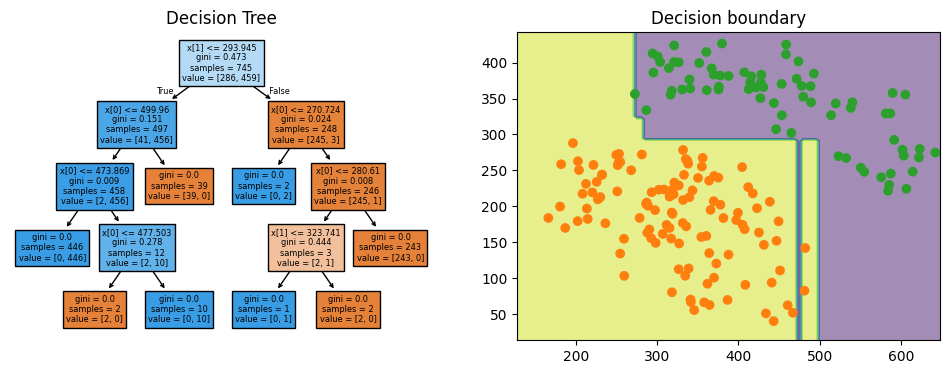

<Figure size 640x480 with 0 Axes>

In [5]:
#Get the data from the drawdata widget
X, y = widget.data_as_X_y

#Split into train/test
x_train,x_val,y_train,y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=1907)

#2
#Create, fit and evaluate a Decision Tree 
decision_tree = DecisionTreeClassifier(random_state=1907,max_depth=4)
decision_tree.fit(x_train,y_train)
print(f"Train accuracy: {decision_tree.score(x_train,y_train)}")
print(f"Validation accuracy: {decision_tree.score(x_val,y_val)}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

tree.plot_tree(decision_tree, filled=True, ax=ax[0])
ax[0].set_title("Decision Tree")

#Plot model's decision boundary and val data
plt.figure()
DecisionBoundaryDisplay.from_estimator(decision_tree,x_train,alpha=0.5, ax=ax[1])
ax[1].scatter(x_val[:,0],x_val[:,1],c=y_val)
ax[1].set_title("Decision boundary")
plt.show()


## Exercise 2: Random Forest
* Use sklearn or drawdata to get a dataset
* Train and evaluate [Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) with different hyper-parameters (number of trees, maximum depth)
* Optionally, draw validation curves and think what hyperparameter you would choose

In [ ]:
#Create a dataset
X, y = make_classification(n_samples=1000, n_features=2,n_informative=2,n_redundant=0,n_repeated=0,class_sep=0.2,random_state=1907)
#Split into train and test
x_train,x_val,y_train,y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=1907)

n_est_metrics = {"train":[], "val":[]}

print(f"Evaluating n_estimators:")
#Evaluate with different number of trees in the ensemble
n_estimators = [1,5,10,50,100]
for n in n_estimators:
    random_forest = RandomForestClassifier(n_estimators=n,max_depth=1,random_state=1907)
    random_forest.fit(x_train,y_train)

    train_acc = random_forest.score(x_train,y_train)
    val_acc = random_forest.score(x_val,y_val)

    n_est_metrics["train"].append(train_acc)
    n_est_metrics["val"].append(val_acc)

    print(f"n_estimators={n} - train_acc: {train_acc} - val_acc: {val_acc}")


#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "val":[]}

print(f"\nEvaluating max_depth:")
depths = [1,5,10,20,None]
for depth in depths:
    random_forest = RandomForestClassifier(n_estimators=100,max_depth=depth,random_state=1907) 
    random_forest.fit(x_train,y_train)

    train_acc = random_forest.score(x_train,y_train)
    val_acc = random_forest.score(x_val,y_val)

    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["val"].append(val_acc)
    
    print(f"max_depth={depth} - train_acc: {train_acc} - val_acc: {val_acc}")

Evaluating n_estimators:
n_estimators=1 - train_acc: 0.625 - val_acc: 0.575
n_estimators=5 - train_acc: 0.6125 - val_acc: 0.6
n_estimators=10 - train_acc: 0.67125 - val_acc: 0.605
n_estimators=50 - train_acc: 0.6725 - val_acc: 0.625
n_estimators=100 - train_acc: 0.67625 - val_acc: 0.63

Evaluating max_depth:
max_depth=1 - train_acc: 0.67625 - val_acc: 0.63
max_depth=5 - train_acc: 0.76 - val_acc: 0.65
max_depth=10 - train_acc: 0.9025 - val_acc: 0.66
max_depth=20 - train_acc: 1.0 - val_acc: 0.62
max_depth=None - train_acc: 1.0 - val_acc: 0.63


#### Plotting validation curves

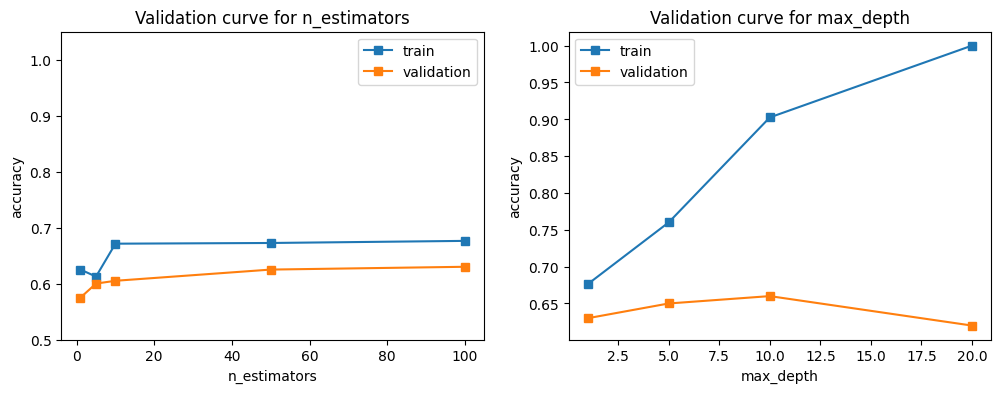

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(n_estimators, n_est_metrics["train"], marker='s', label="train")
ax[0].plot(n_estimators, n_est_metrics["val"], marker='s', label="validation")
ax[0].set_ylim(0.5, 1.05)
ax[0].set_xlabel("n_estimators")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Validation curve for n_estimators")
ax[0].legend()

ax[1].plot(depths, max_depth_metrics["train"], marker='s', label="train")
ax[1].plot(depths, max_depth_metrics["val"], marker='s', label="validation")
ax[0].set_ylim(0.5, 1.05)
ax[1].set_xlabel("max_depth")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Validation curve for max_depth")
ax[1].legend()

## Exercise 3 (bonus): Bagging and/or the Random Subspace Method
* Use the Decision Tree classifier from scikit learn and implement yourself the bagging method and/or the Random Subspace Method

### Bagging

In [ ]:
#Your answer
import random
import select
def train_bagging(x_train, y_train, n_estimators,number_of_selection):
    """
    params:
        - training_data: All training samples with both X (features) and y (groundtruth)
        - n_estimators: Number of tree in the ensemble
        - number_of_selection: Number of random selection with replacement to create the training dataset
    return:
        - An ensemble of Decision Tree each fitted with randomly selected data from X
    """
    lst_classifier = []
    for _ in range(n_estimators):
        #Create the model to train
        current_tree = DecisionTreeClassifier(random_state=1907)

        #Randomly select n points with replacement from the original training set
        indices = np.random.choice(len(x_train), size=number_of_selection, replace=True)

        x_sample = x_train[indices]
        y_sample = y_train[indices]

        #Train the model with the selected points
        current_tree.fit(x_sample,y_sample)
        lst_classifier.append(current_tree)

    return lst_classifier

def eval_bagging(lst_classifier,x_val,y_val):
    """
    params:
        - lst_classifier: Ensemble to evaluate
        - X_val: features of the validation set
        - y_val: groundtruth of the validation set
    """
    preds_classifiers = []
    #Classify each point with every model in the ensemble
    for classifier in lst_classifier:
        preds_classifiers.append(classifier.predict(x_val))
    #Transform into numpy array to use slicing later
    preds_classifiers = np.array(preds_classifiers)

    
    #For each point choose the class with the most vote among the classifiers
    final_preds = []
    for i in range(len(x_val)):
        #Get all predictions for this point
        point_preds = preds_classifiers[:,i]
        
        #Keep the class with most vote
        most_voted_class = max(point_preds, key=list(point_preds).count)
        final_preds.append(most_voted_class)

    #Compare with groundtruth
    nb_good_prediction = sum(final_preds==y_val)
    print(f"Accuracy of the ensemble: {nb_good_prediction/len(y_val)}")

In [73]:
lst_classifier = train_bagging(x_train, y_train, 30, len(x_train))
eval_bagging(lst_classifier,x_val,y_val)

Accuracy of the ensemble: 0.61


In [74]:
x_train.shape[1]

2

**Your comments:**

### Random subspace method

In [77]:
def train_RSM(x_train, y_train, n_estimators, number_of_selection):
    """
    params:
        - training_data: All training samples with both X (features) and y (groundtruth)
        - n_estimators: Number of tree in the ensemble
        - number_of_selection: Number of random selection of feature without replacement to create the training dataset
    return:
        - An ensemble of Decision Tree each fitted with randomly selected data from X
    """
    lstModel = []
    
    for _ in range(n_estimators):
        #Create the model to train
        current_model = DecisionTreeClassifier(random_state=1907)
        
        #Randomly select the features used by this tree
        selected_features = np.random.choice(x_train.shape[1], size=number_of_selection, replace=False)
        x_subspace = x_train[:, selected_features]

        #Train the model and add to the ensemble, /!\ also keeping the list of features used to also use them during prediction /!\
        current_model.fit(x_subspace,y_train)
        lstModel.append((current_model,selected_features))

    return lstModel

def eval_RSM(lst_classifier, x_val, y_val):
    ensemblePrediction = []
    #For each model in the ensemble, use only the features selected during training for this model and make the prediction
    for model in lst_classifier:
        m = model[0]
        selected_features = model[1]
        x_subspace = x_val[:, selected_features]
        ensemblePrediction.append(m.predict(x_subspace))
    #Transform into numpy array for slicing
    ensemblePrediction = np.array(ensemblePrediction)

    #For each point choose the class with the most vote among the classifiers
    pred = []
    for i in range(len(x_val)):
        preds = ensemblePrediction[:,i]
        pred.append(max(preds,key=list(preds).count))

    #Compare with groundtruth
    nb_good_prediction = sum(pred==y_val)
    print(f"Accuracy of the ensemble: {nb_good_prediction/len(y_val)}")

In [78]:
lst_classifier = train_RSM(x_train, y_train, 30, x_train.shape[1])
eval_RSM(lst_classifier,x_val,y_val)

Accuracy of the ensemble: 0.575
